In [112]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
import tqdm
import pickle
from time import time_ns
from src.data_import import *
from src.train import train_one_epoch_TC, train_one_epoch
from src.model import EBM

In [113]:
class ToyEnergyHead(nn.Module):
    def __init__(self, mid=8):
        super().__init__()
        self.net = nn.Sequential(
            (nn.Linear(1, mid)),
            nn.ReLU(),
            (nn.Linear(mid, 1)),
        )
    def forward(self, x):
        return self.net(x)

class ToyEBM(nn.Module):
    def __init__(self, mid_dim: int = 4, n_heads: int = 2) -> None:
        super(ToyEBM, self).__init__()
        self.mid_dim = mid_dim
        self.n_heads = n_heads
        self.device = None

        self.heads = nn.ModuleList(
            [ToyEnergyHead(mid=mid_dim) for _ in range(n_heads)]
        )

    def forward(self, x, head_idx=None):
        if head_idx is not None:
            h_o = self.heads[head_idx](x).squeeze(-1)
        else:
            h_o = torch.stack([head(x).squeeze(-1) for head in self.heads], dim=1)
        if h_o.dim() == 1:
            energy = h_o
        else:
            energy = h_o.sum(dim=1)
        return energy, h_o

In [114]:
def plot_model_density(samples, bins=100, x_min=-5, x_max=5):
    x = samples.detach().cpu().view(-1).numpy()
    plt.hist(x, bins=bins, density=True, range=(x_min, x_max))
    plt.title("Sample distribution")
    plt.show()

In [115]:
def plot_density(model, x_min=-2, x_max=2, n_points=1000, device="cpu"):
    model.eval()
    x = torch.linspace(x_min, x_max, n_points, device=device).unsqueeze(-1)
    with torch.no_grad():
        y = model(x).detach().cpu().view(-1).numpy()
    x = x.detach().cpu().view(-1).numpy()

    plt.plot(x, y)
    plt.xlim(x_min, x_max)
    plt.show()

In [116]:
def strange_density(x: torch.Tensor) -> torch.Tensor:
    t1 = torch.exp(-(x**2)/2)*(torch.sin(2*x)**2)
    return t1

class StrangeModule(nn.Module):
    def __init__(self):
        super().__init__()
    def forward(self, x):
        return strange_density(x.squeeze(0))

In [117]:
from src.train import train_one_epoch_TC
from src.information import TotalCorrelationEstimator
from src.sampler import ReplaySampler

model = ToyEBM(mid_dim=50, n_heads=2)
optim = torch.optim.Adam(model.parameters(), lr=1e-3)
sampler = ReplaySampler(model, img_shape=(1,1), buffer_size=500, noise_fraction=0.05)
tc_estim = TotalCorrelationEstimator(1, hidden_dim=4, lr=1e-3)

In [118]:

def sample_from_1d_density(density_fn, n_samples, batch_size=32, M=6, device="cpu"):
    samples = []
    gM = lambda x: M * ((2 * torch.pi) ** (-1)) * torch.exp(-x**2)

    while len(samples) < n_samples:
        x = torch.randn(1, 1, device=device) * M
        u = torch.rand(1, device=device)

        with torch.no_grad():
            fx = density_fn(x)

        accepted = fx / gM(x)

        if accepted < u:
            samples.append(x.view(-1))

    samples = torch.cat(samples)[:n_samples]
    samples = samples.unsqueeze(-1).unsqueeze(-1).unsqueeze(-1)

    dataset = TensorDataset(samples, torch.rand_like(samples))
    return DataLoader(dataset, batch_size=batch_size, shuffle=True)

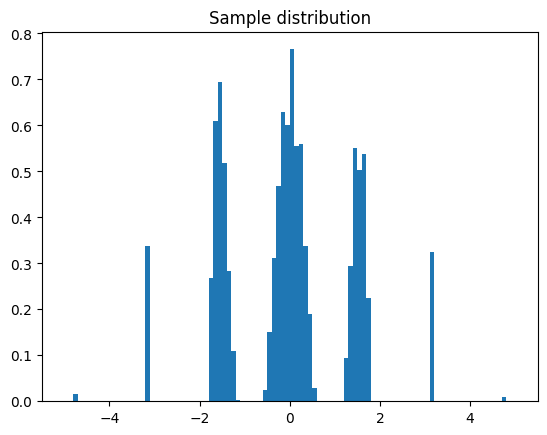

In [119]:
module = StrangeModule()
samples = sample_from_1d_density(module, 32 * 100)
plot_model_density(torch.cat([s[0] for s in samples], dim=0))

In [120]:
for epoch in range(20):
    epoch_loss, _ = train_one_epoch_TC(
        model, 
        sampler, 
        samples, 
        optim,

        sample_steps=40,
        sample_step_size=0.1,
        sample_noise_std=0.005,
        energy_reg=1e-1,
        tc_regularizations=1e-2,
        
        tc_estimator=tc_estim,
        device=torch.device("cpu")
    )
    print(f"Epoch {epoch+1}, Loss: {epoch_loss:.4f}")


100%|██████████| 100/100 [00:02<00:00, 36.47it/s]


Epoch 1, Loss: -0.1181


100%|██████████| 100/100 [00:02<00:00, 36.12it/s]


Epoch 2, Loss: -0.3740


100%|██████████| 100/100 [00:02<00:00, 35.29it/s]


...

Epoch 18, Loss: -1.0022


100%|██████████| 100/100 [00:02<00:00, 36.75it/s]


Epoch 19, Loss: -0.9809


100%|██████████| 100/100 [00:02<00:00, 36.66it/s]

Epoch 20, Loss: -0.9431


In [121]:
class WholeModel(nn.Module):
    
    def __init__(self, m):
        super().__init__()
        self.m = m

    def forward(self, x):
        return torch.exp(self.m(x)[0])


class SingleHead(nn.Module):
    
    def __init__(self, m):
        super().__init__()
        self.m = m

    def forward(self, x):
        return torch.exp(self.m(x))
    
f = WholeModel(model)
h1 = SingleHead(model.heads[0])
h2 = SingleHead(model.heads[1])

Model sampled distribution

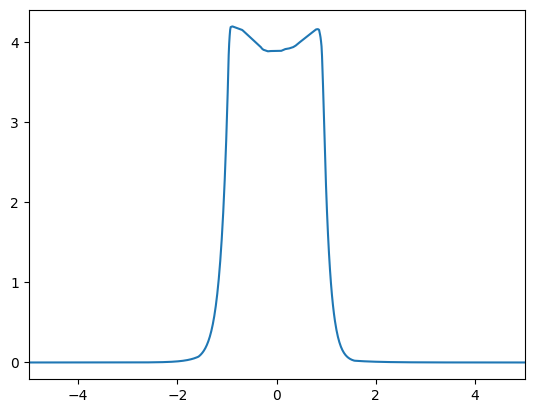

In [122]:
plot_density(f,x_min=-5, x_max=5)

First head distribution

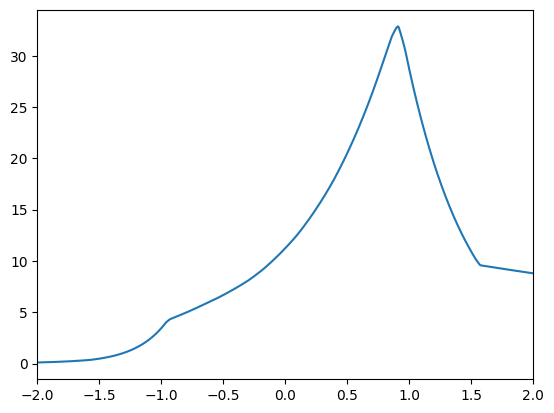

In [123]:
plot_density(h1 ,x_min=-2, x_max=2)

Second head distribution

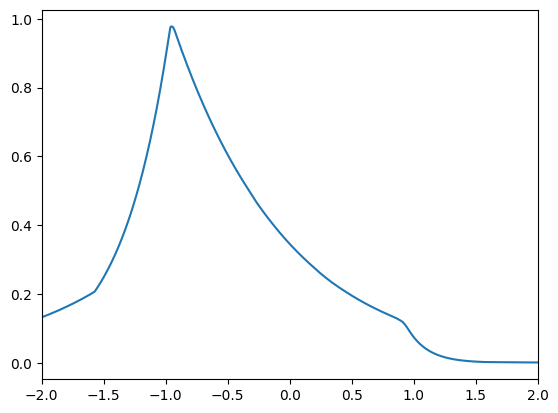

In [124]:
plot_density(h2,x_min=-2, x_max=2)